In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.graph_color import color_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian
from copy import copy
from koala.lattice import INVALID
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)
from tqdm import tqdm

import matplotlib as mpl
from collections import Counter

from dimer_models.kasteleyn import find_kasteleyn_number

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


mpl.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)

import pickle

In [3]:
results = []
with open("single_strip.pkl", "rb") as f:
    while True:
        try:
            results.append(pickle.load(f))
        except EOFError:
            break

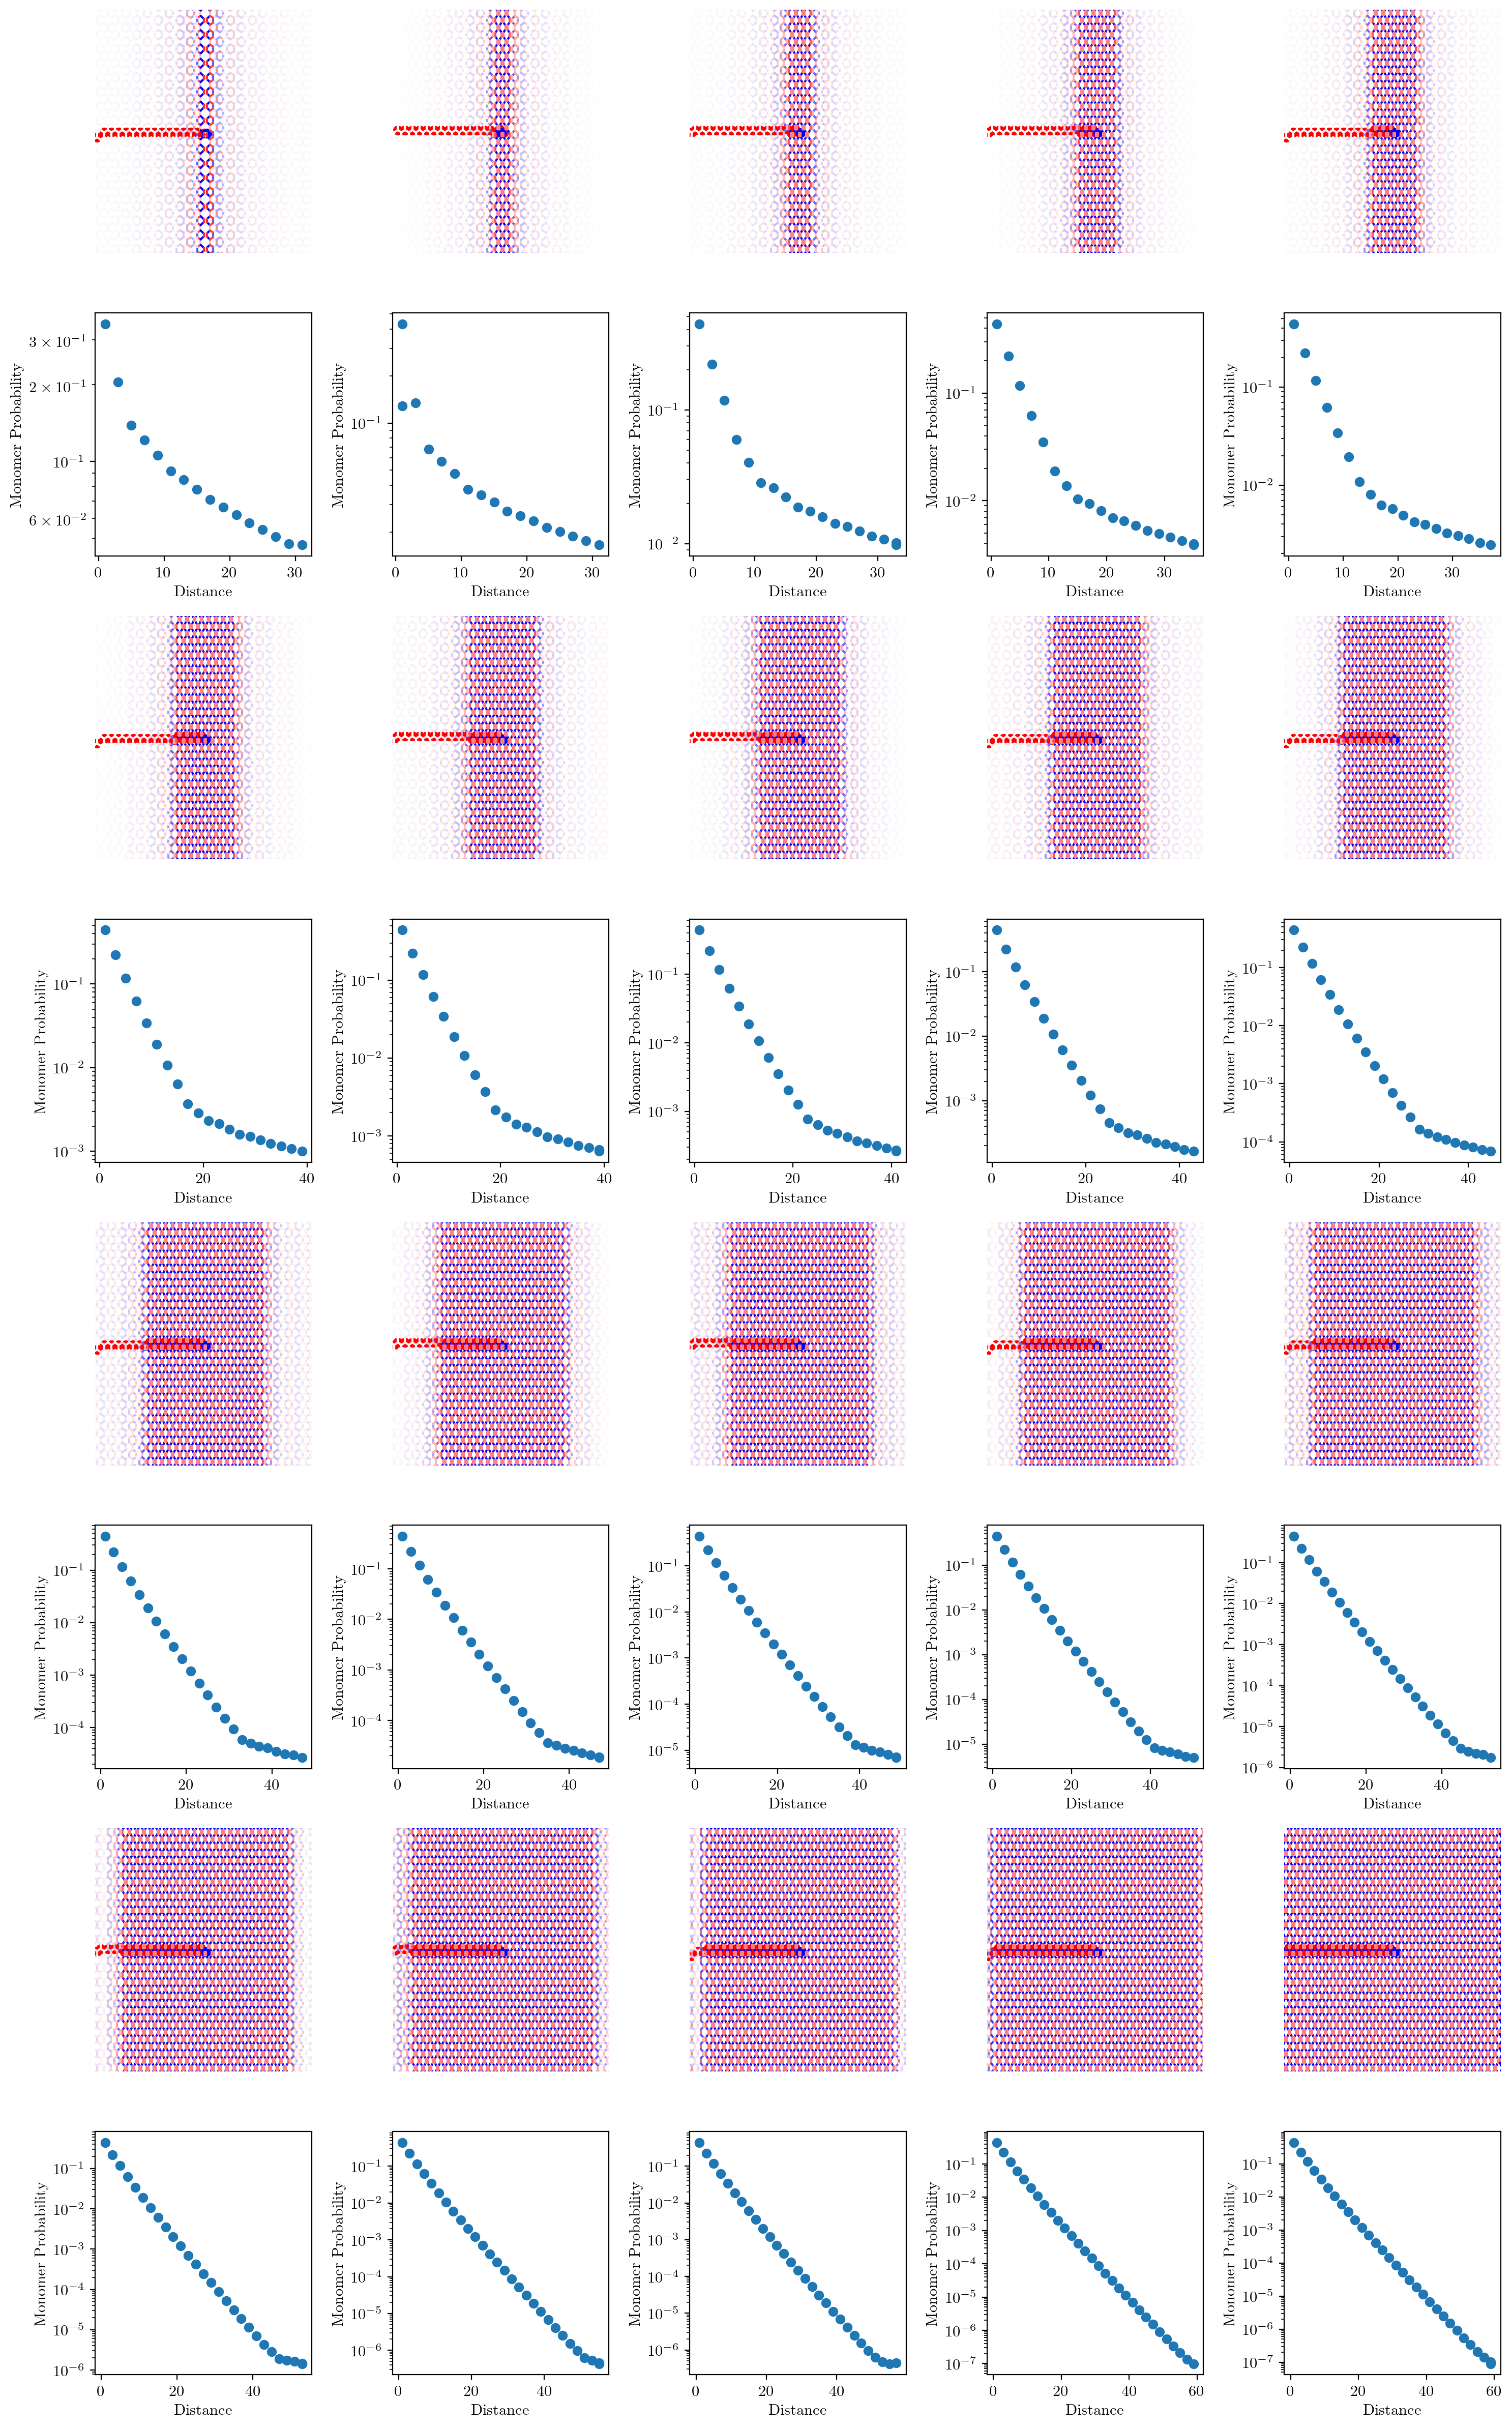

In [4]:
n_results = len(results)
fig, ax = plt.subplots(
    8, n_results // 4, figsize=3 * np.array([n_results // 4, 8]), dpi=200
)
plot_axes = ax[::2].flatten()
graph_axes = ax[1::2].flatten()

for j, res in enumerate(results):

    lattice = res["lattice"]

    # plot the graph
    probs_normalised = res["probs"] - 1 / 3
    probs_normalised = 0.5 * probs_normalised / np.max(np.abs(probs_normalised))
    edge_labels = np.arange(lattice.n_edges)
    cmap = plt.get_cmap("bwr")
    color_scheme = cmap(probs_normalised + 0.5)  # Shift to center around 0
    pl.plot_edges(
        lattice,
        ax=plot_axes[j],
        labels=edge_labels,
        color_scheme=color_scheme,
    )
    plot_axes[j].set_axis_off()
    v2_candidates = res["v2_options"]
    v2_positions = lattice.vertices.positions[v2_candidates]
    v1_position = lattice.vertices.positions[res["v1"]]

    plot_axes[j].scatter(*v2_positions.T, color="red")
    plot_axes[j].scatter(*v1_position, color="blue", label="v1")

    # plot the monomer probabilities
    monomer_prob = res["monomer_prob"]
    distances = res["distances"]
    graph_axes[j].scatter(
        distances,
        monomer_prob,
    )
    graph_axes[j].set_xlabel("Distance")
    graph_axes[j].set_ylabel("Monomer Probability")
    graph_axes[j].set_yscale("log")

plt.tight_layout()
plt.savefig("single_strip_results.png", dpi=300, bbox_inches="tight")